In [54]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import seaborn as sns

In [55]:
live = pd.read_csv("../data/samples/trial/live_metrics.csv")
verbose = pd.read_csv("../data/samples/trial/verbose_statements.csv")
initial = pd.read_csv("../data/samples/trial/initial_statement.csv")

In [56]:
live = live.drop(['Unnamed: 0', "_id", "Category", "Collect", "Current Time"], axis=1)

In [57]:
response_time = verbose['total_duration'].tolist()
eval_rate = verbose['eval_rate'].tolist()
response_time = response_time[:-1]
reset_iters = live[live['Iteration'] == 1].index.tolist()

# gpu_util_avg = []
# memory_util_avg = []
# clock_util_avg = []

# for i in range(1, len(reset_iters)):
#     temp_metrics = live.dropna()
#     gpu_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 3].tolist()
#     memeory_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], 9].tolist()
#     clock_util_prompt= temp_metrics.iloc[reset_iters[i-1]:reset_iters[i], -2].tolist()
#     gpu_util_avg.append(np.average(gpu_util_prompt))
#     memory_util_avg.append(np.average(memeory_util_prompt))
#     clock_util_avg.append(np.average(clock_util_prompt))

In [58]:
eval_rates = [np.float64(evals[:-9]) for evals in eval_rate]

In [59]:
live = live.dropna()
live.corr()

,GPU Utilization (%),Power Draw (Watts),GPU Temp (°C),GPU Current Clock (MHz),Memory Current Clock (MHz),Memory Allocation Used (MB),Memory Utilization (%),Time Delta,Iteration,GPU Clock Utilization,Memory Clock Utilization
GPU Utilization (%),1.000000,0.593940,0.850593,0.566516,NaN,0.558457,0.984606,0.229794,0.193269,0.566516,NaN
Power Draw (Watts),0.593940,1.000000,0.632645,0.940428,NaN,0.926230,0.582237,0.133995,0.169276,0.940428,NaN
GPU Temp (°C),0.850593,0.632645,1.000000,0.648092,NaN,0.638945,0.834220,0.447632,0.070172,0.648092,NaN
GPU Current Clock (MHz),0.566516,0.940428,0.648092,1.000000,NaN,0.984983,0.561601,0.204359,0.070822,1.000000,NaN
Memory Current Clock (MHz),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory Allocation Used (MB),0.558457,0.926230,0.638945,0.984983,NaN,1.000000,0.554592,0.202557,0.068923,0.984983,NaN
Memory Utilization (%),0.984606,0.582237,0.834220,0.561601,NaN,0.554592,1.000000,0.265147,0.119363,0.561601,NaN
Time Delta,0.229794,0.133995,0.447632,0.204359,NaN,0.202557,0.265147,1.000000,-0.493056,0.204359,NaN
Iteration,0.193269,0.169276,0.070172,0.070822,NaN,0.068923,0.119363,-0.493056,1.000000,0.070822,NaN
GPU Clock Utilization,0.566516,0.940428,0.648092,1.000000,NaN,0.984983,0.561601,0.204359,0.070822,1.000000,NaN


In [60]:
live = live.drop(columns=['Memory Clock Utilization', 'Memory Current Clock (MHz)'])

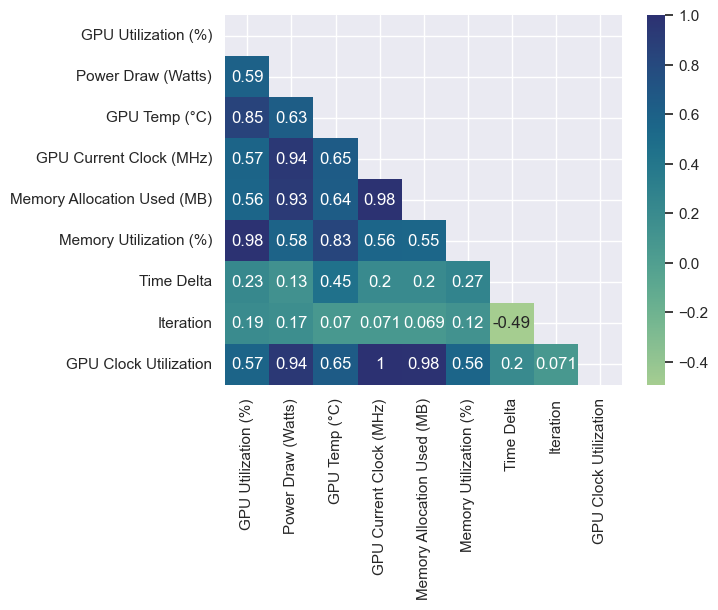

In [61]:
mask = np.triu(np.ones_like(live.corr(), dtype=bool))
heatmap = sns.heatmap(live.corr(), mask=mask, annot=True, cmap="crest")

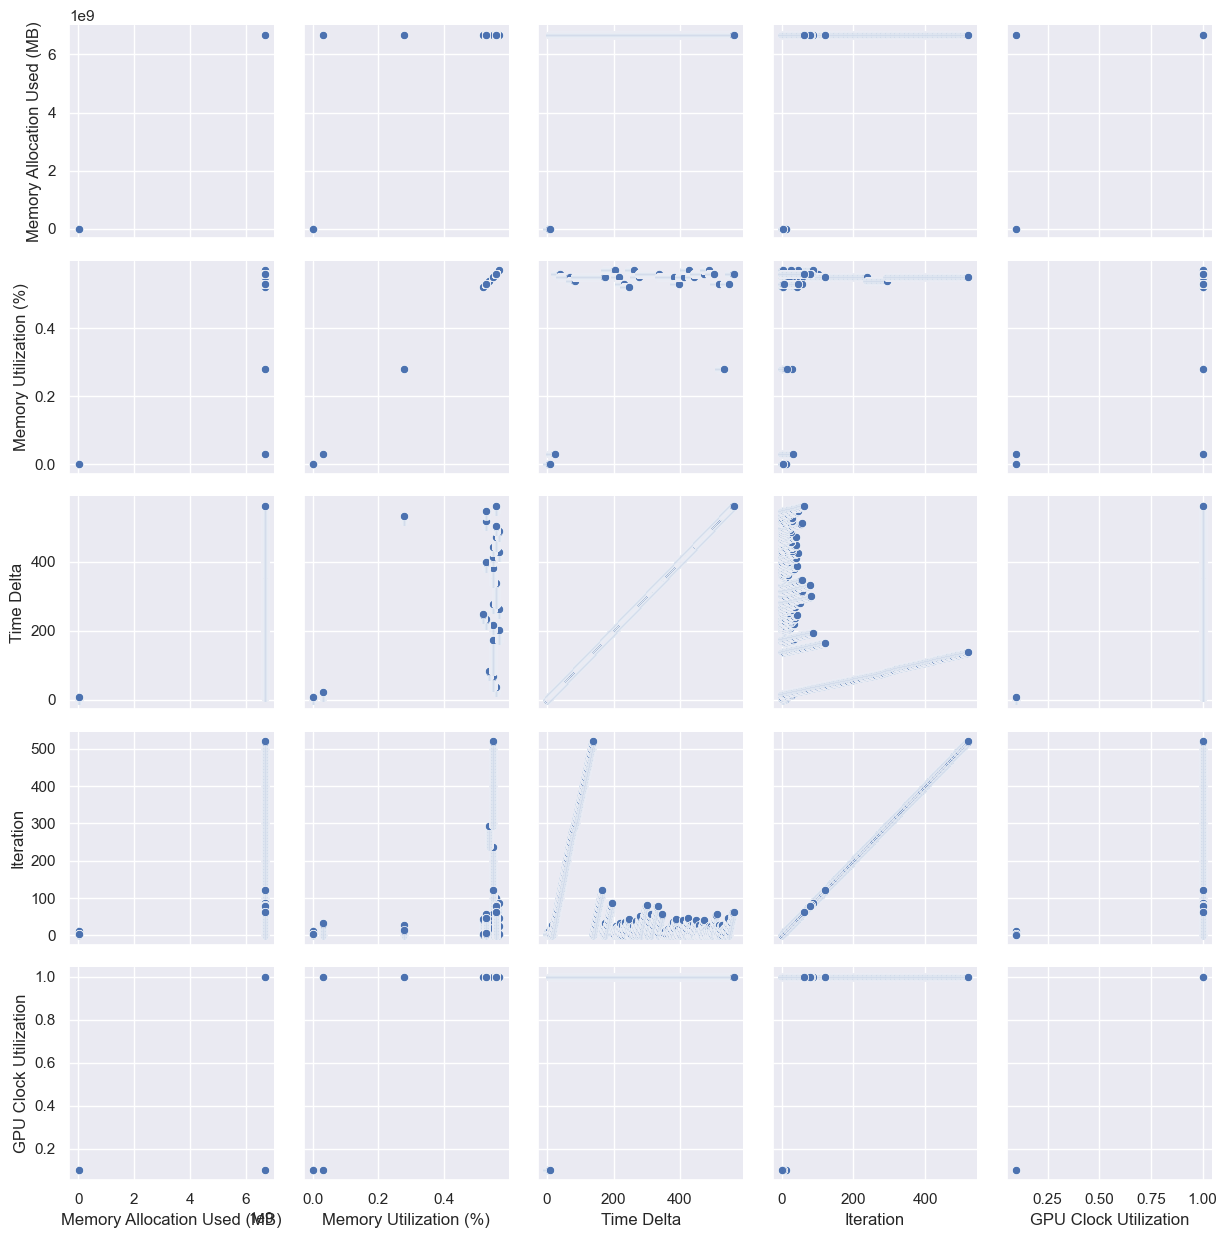

In [62]:
sns.set_theme()
g = sns.PairGrid(live.iloc[:, 4:])
plot = g.map(sns.scatterplot)
# sns.pairplot(live.iloc[:, 4:], corner=True)

In [63]:
# X = pd.DataFrame([gpu_util_avg, memory_util_avg, clock_util_avg])
# X = X.T
# X.columns = ['GPU Util', "Memory Util", "GPU Clock"]
X_sam = live
# y = pd.DataFrame(response_time, columns=['AVG Response Time'])
y = np.array(response_time)

In [64]:
column_names = live.columns.tolist()
live_avg = dict(zip(column_names, [list(range(70))] * len(column_names)))
live_avg = pd.DataFrame(live_avg, dtype=np.float64)

In [65]:
for iter in range(1, len(reset_iters)):
    for column in live.columns:
        temp_list = live.iloc[reset_iters[iter-1]:reset_iters[iter],  column_names.index(column)].tolist()
        live_avg.iloc[iter-1, column_names.index(column)] = np.float64(np.average(temp_list))

In [66]:
live_avg = live_avg.iloc[:-1,:]

In [67]:
from sklearn.preprocessing import normalize, StandardScaler

live_avg = normalize(live_avg)
ss = StandardScaler()
live_avg = ss.fit_transform(live_avg)

In [68]:
live_avg

array([[-3.29348058,  4.68726489,  4.69007267,  4.68888495, -4.69037411,
        -3.28960119, -1.7470194 ,  4.58300637,  4.68888495],
       [-3.29348058,  4.68726489,  4.69007267,  4.68888495, -4.69037411,
        -3.28960119, -1.0171364 ,  1.16973721,  4.68888495],
       [-3.29348058,  4.68726489,  4.69007267,  4.68888495, -4.69037411,
        -3.28960119, -0.3393879 ,  5.11661718,  4.68888495],
       [-3.15829821, -0.35745017, -0.23506447, -0.42371893,  0.24793599,
        -3.09224038, -2.38931807, -0.42516259, -0.42371893],
       [-3.1143111 , -0.23022068, -0.27877292, -0.20922021,  0.2125429 ,
        -3.09341603, -2.40849607, -0.44287509, -0.20922021],
       [-3.1143111 , -0.23022068, -0.27877292, -0.20922021,  0.2125429 ,
        -3.09341603, -2.37774777, -0.26002572, -0.20922021],
       [ 0.26808247, -0.18277691, -0.22340689, -0.2095782 ,  0.21260772,
         0.13807512, -1.91841077,  3.82180122, -0.2095782 ],
       [ 0.40714639, -0.17241627, -0.20505987, -0.20959699,  0

In [69]:
X_train, X_test, y_train, y_test = train_test_split(live_avg, y, test_size=0.2, shuffle=True, random_state=20)

In [70]:
lcv = LassoCV(cv=3)
lcv.fit(X_train, y_train)
score = lcv.score(X_test, y_test)
print(f"Accuracy: {score}")

Accuracy: -91.62489434115068


c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.3401607594947791, tolerance: 0.15253541373886317
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.3940034056679451, tolerance: 0.15253541373886317
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.3904748086863492, tolerance: 0.15253541373886317
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\rahul\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.p

In [71]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso, Ridge

rfe = RFE(estimator=Ridge(), n_features_to_select=2, verbose=True)


In [72]:
rfe.fit(X_train, y_train)
rfe.score(X_test, y_test)

Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.


-89.0946337089728

In [73]:
dict(zip(live.columns.tolist(), rfe.support_))

{'GPU Utilization (%)': False,
 'Power Draw (Watts)': False,
 'GPU Temp (°C)': True,
 'GPU Current Clock (MHz)': False,
 'Memory Allocation Used (MB)': False,
 'Memory Utilization (%)': False,
 'Time Delta': False,
 'Iteration': True,
 'GPU Clock Utilization': False}